Name Isabelle Maru Shapiro 

Labpartner(s)

In [1]:
#import statements go here


# Class 7.2

Today your assignment is the rest of the pandas unit and to catch up and think about your project topic, which is due by Sunday 10/13.

**W.1** Implement a function that takes as input three variables, and returns the largest of the three. Do this without using the Python max() function.

The goal of this exercise is to think about some internals that Python normally takes care of for us. All you need is some variables and if statements.

In [13]:
a = 1000
b = 700
c = 5000

def largest(x,y,z):
    if x > y:
        large = x
    else:
        large = y

    if large > z:
        print(large)
    else:
        print(z)

largest(a,b,c)

5000


# Lecture 7.2

### Agenda:

- Questions
- Tropical Tidbits
- Movie project!

### Questions

In [15]:
%pip install geopandas

   ---------------------------------------- 0.0/23.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/23.8 MB ? eta -:--:--
    --------------------------------------- 0.5/23.8 MB 1.8 MB/s eta 0:00:13
    --------------------------------------- 0.5/23.8 MB 1.8 MB/s eta 0:00:13
    --------------------------------------- 0.5/23.8 MB 1.8 MB/s eta 0:00:13
    --------------------------------------- 0.5/23.8 MB 1.8 MB/s eta 0:00:13
   - -------------------------------------- 0.8/23.8 MB 528.0 kB/s eta 0:00:44
   -- ------------------------------------- 1.6/23.8 MB 1.0 MB/s eta 0:00:22
   --- ------------------------------------ 2.1/23.8 MB 1.2 MB/s eta 0:00:18
   --- ------------------------------------ 2.4/23.8 MB 1.3 MB/s eta 0:00:17
   ---- ----------------------------------- 2.6/23.8 MB 1.3 MB/s eta 0:00:16
   ---- ----------------------------------- 2.9/23.8 MB 1.3 MB/s eta 0:00:17
   ----- ---------------------------------- 3.1/23.8 MB 1.3 MB/s eta 0:00:16
   ------ -

EPSG:4326


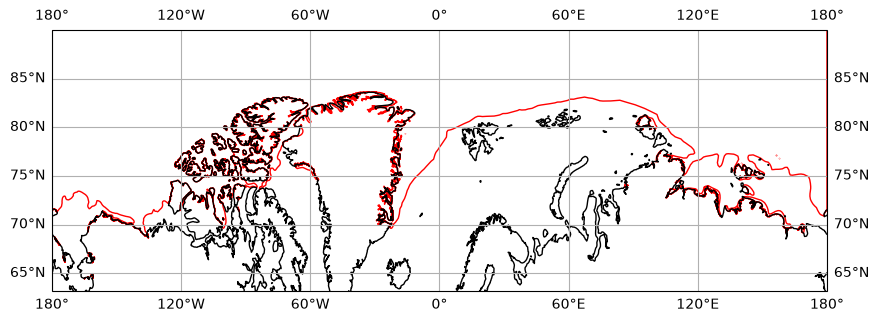

In [1]:
# How to open a shapefile in python
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


gdf = gpd.read_file("nic_autoc2026281n_pl_a.shp")

#Coordinate system:
print(gdf.crs)

# Make map
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add shapefile
gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=1
)

ax.coastlines()
ax.gridlines(draw_labels=True)

plt.show()

For our project this week, I am unleashing you use LLMs for coding, and specifically how to make a series of images into a playable movie. For example, say you have a series of daily HYCOM SST plots, and you want to animate this, how would you do it? We'll strategize more in class about how to accomplish this as a team and with the help of ChatGPT, Claude, or whatever, and hopefully come up with a few different workflows you can share. 

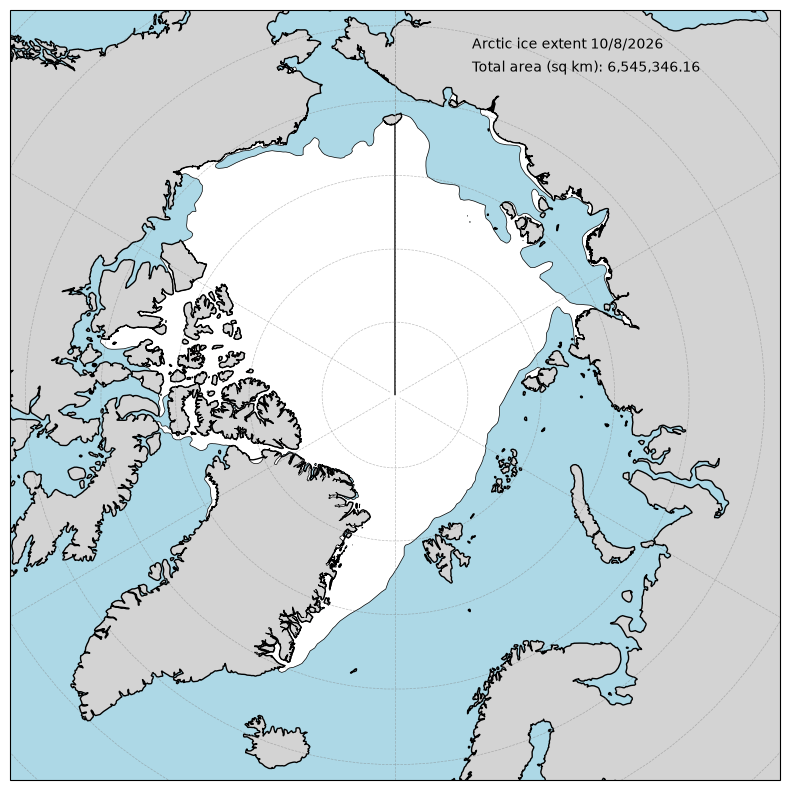

In [56]:
#plotting shp file that looks nice

import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

#Data for this year:
gdf = gpd.read_file("nic_autoc2026281n_pl_a.shp")

# make Projection at pole
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

# Center around boundaries of shpfile
ax.set_extent([-180, 180, 64, 90],crs=ccrs.PlateCarree())

#Add shapfile "geometries"
ax.add_geometries(gdf.geometry, crs=ccrs.PlateCarree(), facecolor="white", edgecolor="black", linewidth=0.5)

#add details 
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=0)
ax.coastlines(resolution="50m")
ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")

#Add name
ax.text(0.6,0.95,"Arctic ice extent 10/8/2026", transform = ax.transAxes)

#calculate area of shapefile and add to map
gdf_area = gdf.to_crs("+proj=laea +lat_0=90 +lon_0=0 +datum=WGS84")
total_area_km2 = gdf_area.geometry.area.sum() / 1e6
ax.text(0.6,0.92,f"Total area (sq km): {total_area_km2:,.2f}", transform = ax.transAxes)


plt.savefig("2026_ice.png", dpi=300)

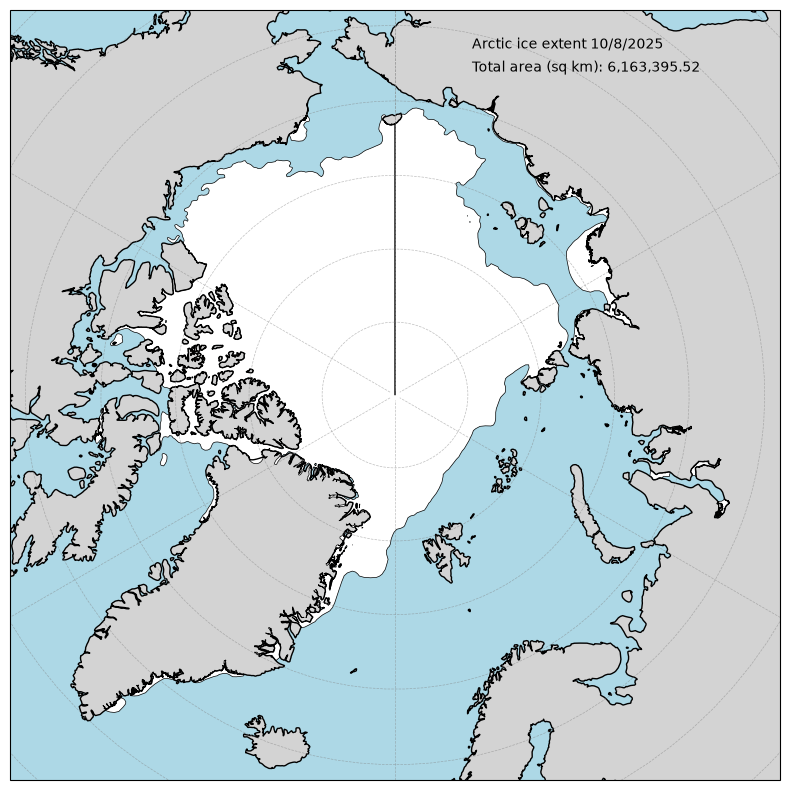

In [57]:
# This year data"
gdf = gpd.read_file("nic_autoc2025281n_pl_a.shp")

# make Projection at pole
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

# Center around boundaries of shpfile
ax.set_extent([-180, 180, 64, 90],crs=ccrs.PlateCarree())

#Add shapfile "geometries"
ax.add_geometries(gdf.geometry, crs=ccrs.PlateCarree(), facecolor="white", edgecolor="black", linewidth=0.5)

#add details 
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=0)
ax.coastlines(resolution="50m")
ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")

#Add name
ax.text(0.6,0.95,"Arctic ice extent 10/8/2025", transform = ax.transAxes)

#calculate area of shapefile and add to map
gdf_area = gdf.to_crs("+proj=laea +lat_0=90 +lon_0=0 +datum=WGS84")
total_area_km2 = gdf_area.geometry.area.sum() / 1e6
ax.text(0.6,0.92,f"Total area (sq km): {total_area_km2:,.2f}", transform = ax.transAxes)


plt.savefig("2025_ice.png", dpi=300)

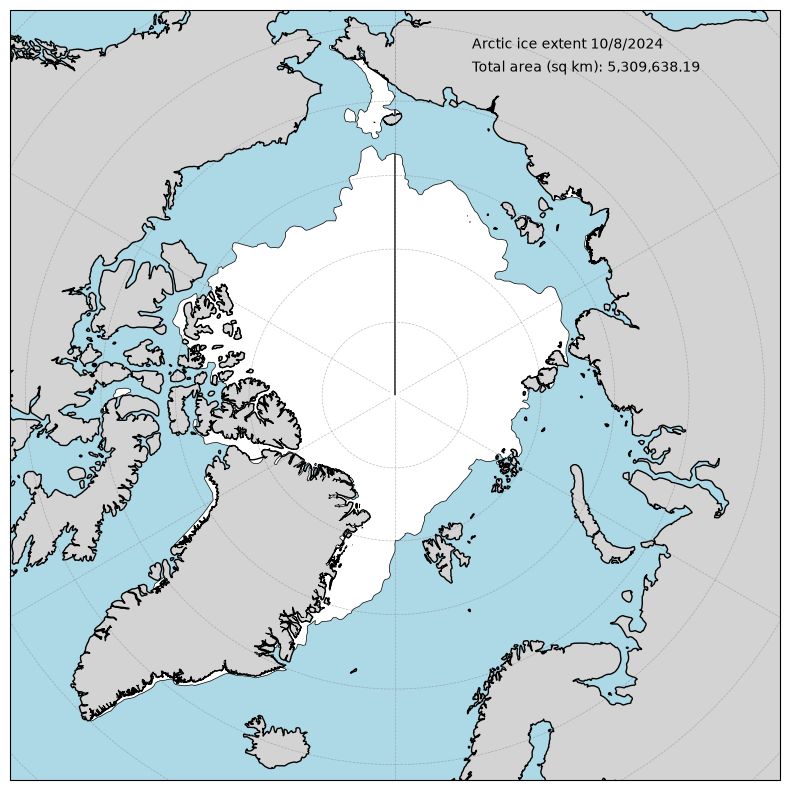

In [58]:
# This year data:

gdf = gpd.read_file("nic_autoc2024282n_pl_a.shp")
# make Projection at pole
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

# Center around boundaries of shpfile
ax.set_extent([-180, 180, 64, 90],crs=ccrs.PlateCarree())

#Add shapfile "geometries"
ax.add_geometries(gdf.geometry, crs=ccrs.PlateCarree(), facecolor="white", edgecolor="black", linewidth=0.5)

#add details 
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=0)
ax.coastlines(resolution="50m")
ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")

#Add name
ax.text(0.6,0.95,"Arctic ice extent 10/8/2024", transform = ax.transAxes)

#calculate area of shapefile and add to map
gdf_area = gdf.to_crs("+proj=laea +lat_0=90 +lon_0=0 +datum=WGS84")
total_area_km2 = gdf_area.geometry.area.sum() / 1e6
ax.text(0.6,0.92,f"Total area (sq km): {total_area_km2:,.2f}", transform = ax.transAxes)


plt.savefig("2024_ice.png", dpi=300)

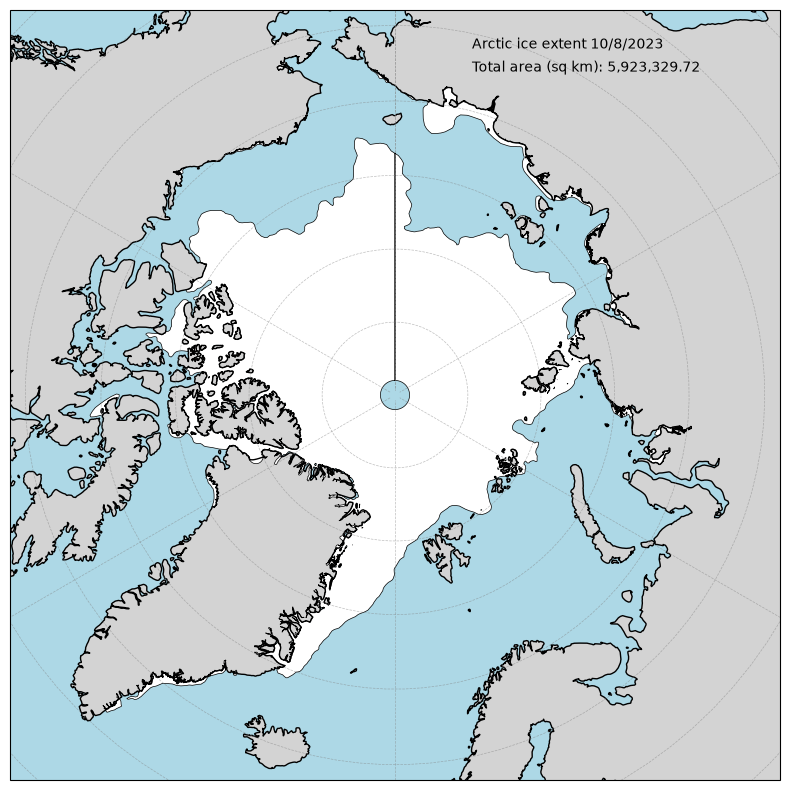

In [59]:
# This year data:

gdf = gpd.read_file("nic_autoc2023281n_pl_a.shp")
# make Projection at pole
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

# Center around boundaries of shpfile
ax.set_extent([-180, 180, 64, 90],crs=ccrs.PlateCarree())

#Add shapfile "geometries"
ax.add_geometries(gdf.geometry, crs=ccrs.PlateCarree(), facecolor="white", edgecolor="black", linewidth=0.5)

#add details 
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=0)
ax.coastlines(resolution="50m")
ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")

#Add name
ax.text(0.6,0.95,"Arctic ice extent 10/8/2023", transform = ax.transAxes)

#calculate area of shapefile and add to map
gdf_area = gdf.to_crs("+proj=laea +lat_0=90 +lon_0=0 +datum=WGS84")
total_area_km2 = gdf_area.geometry.area.sum() / 1e6
ax.text(0.6,0.92,f"Total area (sq km): {total_area_km2:,.2f}", transform = ax.transAxes)


plt.savefig("2023_ice.png", dpi=300)

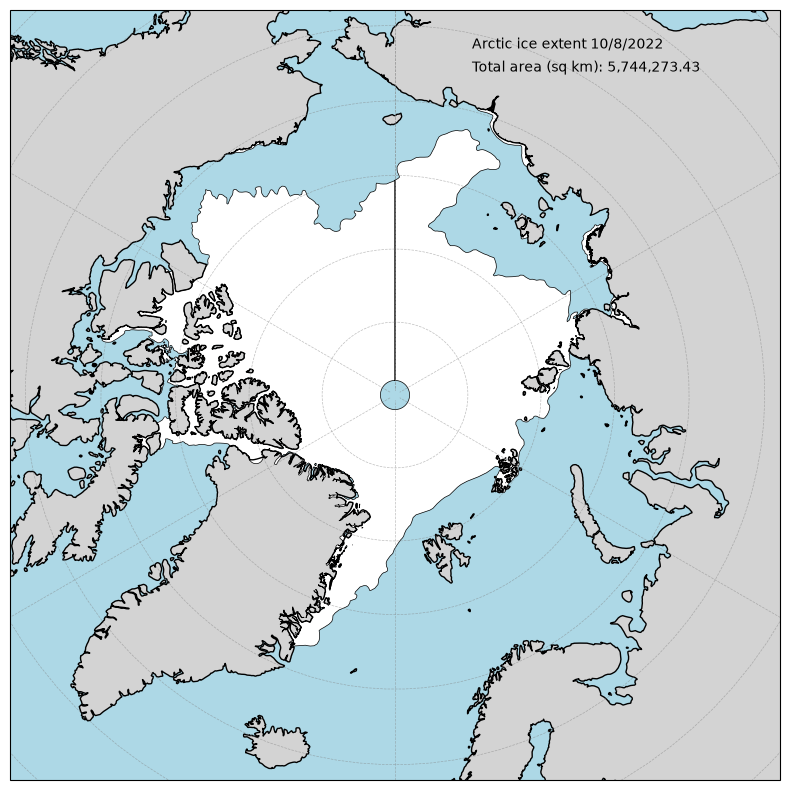

In [60]:
# this year data:
gdf = gpd.read_file("nic_autoc2022281n_pl_a.shp")
# make Projection at pole
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

# Center around boundaries of shpfile
ax.set_extent([-180, 180, 64, 90],crs=ccrs.PlateCarree())

#Add shapfile "geometries"
ax.add_geometries(gdf.geometry, crs=ccrs.PlateCarree(), facecolor="white", edgecolor="black", linewidth=0.5)

#add details 
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=0)
ax.coastlines(resolution="50m")
ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")

#Add name
ax.text(0.6,0.95,"Arctic ice extent 10/8/2022", transform = ax.transAxes)

#calculate area of shapefile and add to map
gdf_area = gdf.to_crs("+proj=laea +lat_0=90 +lon_0=0 +datum=WGS84")
total_area_km2 = gdf_area.geometry.area.sum() / 1e6
ax.text(0.6,0.92,f"Total area (sq km): {total_area_km2:,.2f}", transform = ax.transAxes)


plt.savefig("2022_ice.png", dpi=300)

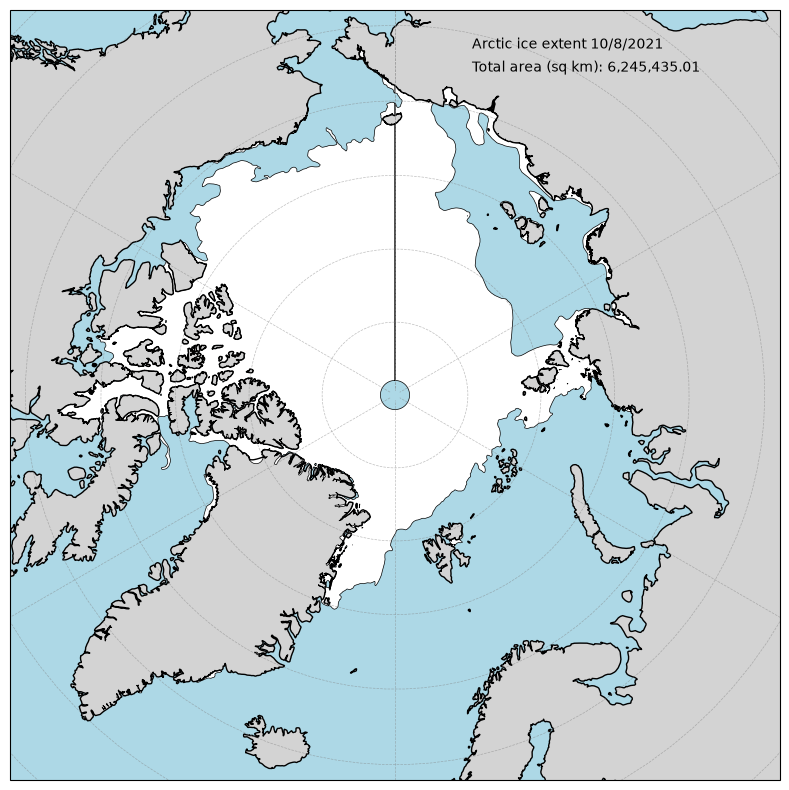

In [61]:
# This year data:
gdf = gpd.read_file("nic_autoc2021281n_pl_a.shp")

# make Projection at pole
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

# Center around boundaries of shpfile
ax.set_extent([-180, 180, 64, 90],crs=ccrs.PlateCarree())

#Add shapfile "geometries"
ax.add_geometries(gdf.geometry, crs=ccrs.PlateCarree(), facecolor="white", edgecolor="black", linewidth=0.5)

#add details 
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=0)
ax.coastlines(resolution="50m")
ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")

#Add name
ax.text(0.6,0.95,"Arctic ice extent 10/8/2021", transform = ax.transAxes)

#calculate area of shapefile and add to map
gdf_area = gdf.to_crs("+proj=laea +lat_0=90 +lon_0=0 +datum=WGS84")
total_area_km2 = gdf_area.geometry.area.sum() / 1e6
ax.text(0.6,0.92,f"Total area (sq km): {total_area_km2:,.2f}", transform = ax.transAxes)


plt.savefig("2021_ice.png", dpi=300)

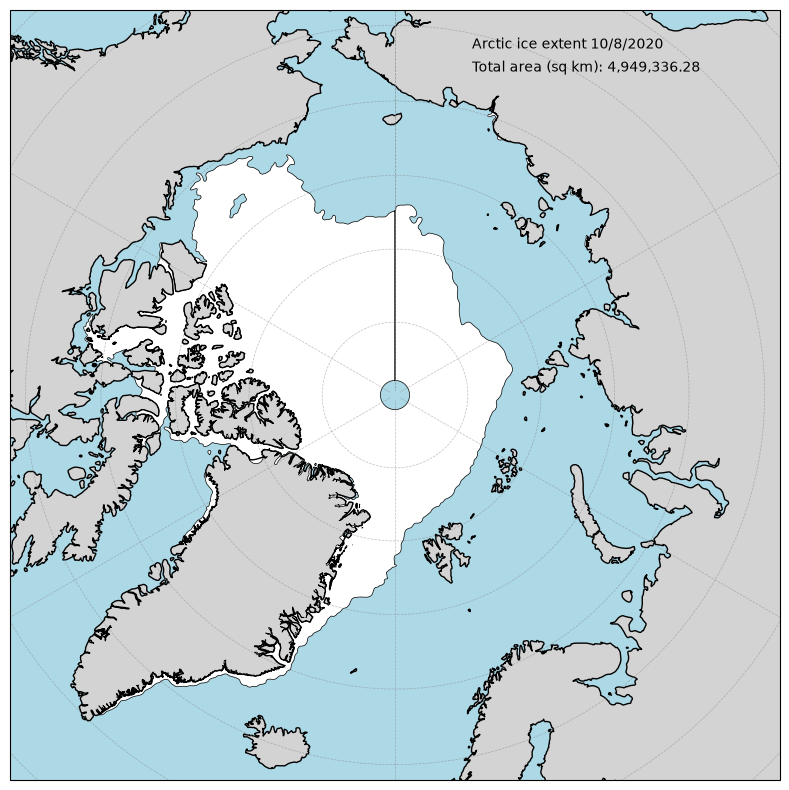

In [62]:
#THis year data"
gdf = gpd.read_file("nic_autoc2020282n_pl_a.shp")

# make Projection at pole
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

# Center around boundaries of shpfile
ax.set_extent([-180, 180, 64, 90],crs=ccrs.PlateCarree())

#Add shapfile "geometries"
ax.add_geometries(gdf.geometry, crs=ccrs.PlateCarree(), facecolor="white", edgecolor="black", linewidth=0.5)

#add details 
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", zorder=0)
ax.coastlines(resolution="50m")
ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")

#Add name
ax.text(0.6,0.95,"Arctic ice extent 10/8/2020", transform = ax.transAxes)

#calculate area of shapefile and add to map
gdf_area = gdf.to_crs("+proj=laea +lat_0=90 +lon_0=0 +datum=WGS84")
total_area_km2 = gdf_area.geometry.area.sum() / 1e6
ax.text(0.6,0.92,f"Total area (sq km): {total_area_km2:,.2f}", transform = ax.transAxes)


plt.savefig("2020_ice.png", dpi=300)

In [63]:
#animate them all together:

from PIL import Image
import glob

#files named 202[something]_ice.png:

files = sorted(glob.glob("202*_ice.png"))

frames = [Image.open(f) for f in files]

frames[0].save("arctic_ice_extent_2020_to_2026.gif", save_all=True, append_images=frames[1:], duration=500, loop=0)

#duration in milisec per frame

# Lab 7.2

**E.0** Complete the previous labs if you are behind.

**E.1** Complete Data Manipulation with Pandas Ch 3-4 in datacamp.

**E.2** Make notes for yourself on progamming tecniques and commands you learned in the datacamp chapter above, including examples, comments and explainitory text. You can do this here or in a separate notebook that you link to here. Basically, you are making a cheat sheet for yourself.

Slicing lists:
List[index:index]

List[:index] ←begining up to index

List[:] ←whole list 

df.set_index([“column1”, “column2”]).sort_index()

Df.loc[“first”:”last index”] ←slice at the outer index level 

df.loc[(“text column1”, “text column 2”):(“text coulmn 1”, text column2”)]<--slice down to second index 

Df.loc[ :, “column1”:”column2”] ←slice columns 

df.loc[ “index 1” :index2”, : ] ←slice at rows 


^ can slice from only begining of index text (ie if you have dates in yyyy-mm-dd, you can just ender yyy and it will slice at those years. 

Can also slice at index number:
df.iloc[#:#,#:#] ← rows: coulmns



df.mean(axis = “index) <-calculate mean across rowws
df.mean(axis = “columns”) ← calculate mena across columns 
Df[“date”].dt.year ← pull out just the years of yyy-mm-dd datetime .  Can also do .month or.day



Df[“column’”. hist(bins = #)

df.groupby(“column1”)[“column2”].mean() ←group by column1, and show the mean of column2 for each group 

series.plot(kind = “bar”)
^ series is a 2d array, aka a dataframe with only two columns.  

series.plot(x = “column1”, y = “column2”, kind = “line, rot = 45”) ← rot is rotate labels 

Also “scatter”, “bar”, “hist”

Df[df[“column1”] == “text”] [“column2”].hist() ←make a histogram of info from column2 only with data that has “Text” in column 1

Plt.legend([“text”, “text”])

.hist(alpha = 0.7) ←make histogram transparent 



df.isna() ←tells you is there are any missing values by giving new df full of false or true 

df.isna().any() ←tells you if there are any missing values per column

df.isna().sum() ←count number of na in each colun 

df.dropna() ←remove rows with missing values 

df.fillna(0) ← replaces nans with given value 

Dictionary = { “key”: value, “key”: value}

Dictionary[“key”]

List of dictionaries  = [{“key1”: value, “key2”: value}, {“key1” :value, “key2” : vaue}]

pd.DataFrame(list of dictionaries) ← turns a list of dictionaries like above into a dataframe 


Dictionary of lists  = { “column1”:[ value, value, value ], “column2” : [value, value, value]} ←where values are the values in each list 



pd.read_csv(“file”)

df.to_csv(“file name”)


**E.3** For this week's project, find a series of images you want to animate. This can be model output, a series of other plots, whatever you want. Everyone needs to pick their own dataset. Work together and share ideas for different ways to make these movies, and work with an LLM to help you figure this out. Next week on Monday or Wednesday you will present your movie and tell us how you made it.

In [ ]:
#see above whoops 

## data from https://usicecenter.gov/Products/ArcticData